In [2]:
import json
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
# CARICAMENTO JSON
json_path = "Results/llm_annotations.json"

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

In [4]:
# funzioni
def get_char_set(chars):
    return set(chars)

def only_children(chars):
    s = get_char_set(chars)
    return len(s) > 0 and s.issubset({"Boy", "Girl"})

def only_adults(chars):
    s = get_char_set(chars)
    return len(s) > 0 and s.issubset({"Man", "Woman"})

def only_women_girls(chars):
    s = get_char_set(chars)
    return len(s) > 0 and s.issubset({"Woman", "Girl"}) and \
           "Woman" in s and "Girl" in s

def only_men_boys(chars):
    s = get_char_set(chars)
    return len(s) > 0 and s.issubset({"Man", "Boy"}) and \
           "Man" in s and "Boy" in s

In [5]:
# statistiche
stats = {
    "only_children": 0,
    "only_adults": 0,
    "only_women_girls": 0,
    "only_men_boys": 0,
}

women_girls_three_quarter = []
men_boys_three_quarter = []

In [6]:
for item in data:

    llm = item["llm_output"]

    # considera solo immagini con illustrazione
    if llm["illustration_present"] != "Yes":
        continue

    chars = llm.get("characters", [])
    faces = llm.get("faces_position", [])
    social = llm.get("social_class", [])

    # SOLO BAMBINI
    if only_children(chars):
        stats["only_children"] += 1

    # SOLO ADULTI
    if only_adults(chars):
        stats["only_adults"] += 1

    # SOLO DONNE + BAMBINE
    if only_women_girls(chars):
        stats["only_women_girls"] += 1

        for face, soc in zip(faces, social):
            if face == "three_quarter_look_down":
                women_girls_three_quarter.append(soc)

    # SOLO UOMINI + BAMBINI
    if only_men_boys(chars):
        stats["only_men_boys"] += 1

        for face, soc in zip(faces, social):
            if face == "three_quarter_look_down":
                men_boys_three_quarter.append(soc)


In [7]:
# risultati
print("\n===== STATISTICHE GENERALI =====\n")

print("Solo bambini (Boy/Girl):", stats["only_children"])
print("Solo adulti (Man/Woman):", stats["only_adults"])
print("Solo donne e bambine:", stats["only_women_girls"])
print("Solo uomini e bambini:", stats["only_men_boys"])


===== STATISTICHE GENERALI =====

Solo bambini (Boy/Girl): 499
Solo adulti (Man/Woman): 1129
Solo donne e bambine: 212
Solo uomini e bambini: 280


In [8]:
# posizione dei volti

women_counter = Counter(women_girls_three_quarter)
men_counter = Counter(men_boys_three_quarter)

print("\n===== DONNE + BAMBINE =====")
print("Volti three_quarter_look_down:",
      sum(women_counter.values()))

print("Classi sociali:")
for k, v in women_counter.items():
    print(f"{k}: {v}")

print("\n===== UOMINI + BAMBINI =====")
print("Volti three_quarter_look_down:",
      sum(men_counter.values()))

print("Classi sociali:")
for k, v in men_counter.items():
    print(f"{k}: {v}")


===== DONNE + BAMBINE =====
Volti three_quarter_look_down: 94
Classi sociali:
Middle Class: 52
Poor: 12
Working Class: 18
None: 3
Upper Class: 9

===== UOMINI + BAMBINI =====
Volti three_quarter_look_down: 132
Classi sociali:
Working Class: 47
Middle Class: 54
Poor: 17
Upper Class: 12
None: 2


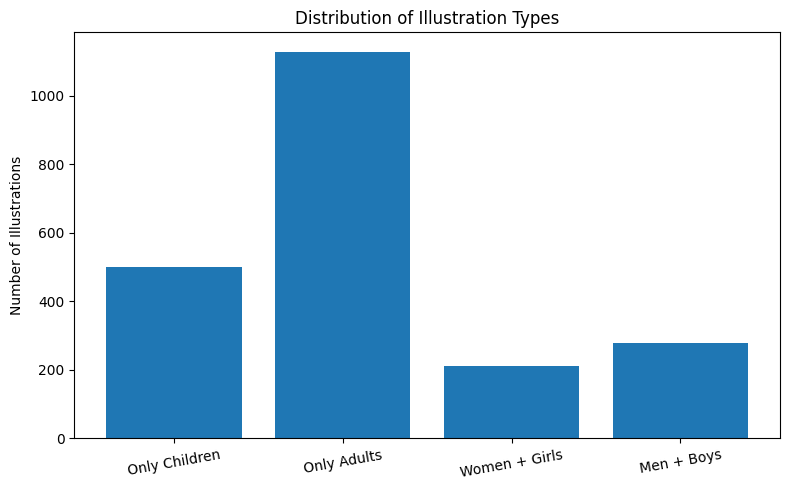

In [9]:
# grafico

labels = [
    "Only Children",
    "Only Adults",
    "Women + Girls",
    "Men + Boys"
]

values = [
    stats["only_children"],
    stats["only_adults"],
    stats["only_women_girls"],
    stats["only_men_boys"]
]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)

plt.title("Distribution of Illustration Types")
plt.ylabel("Number of Illustrations")
plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

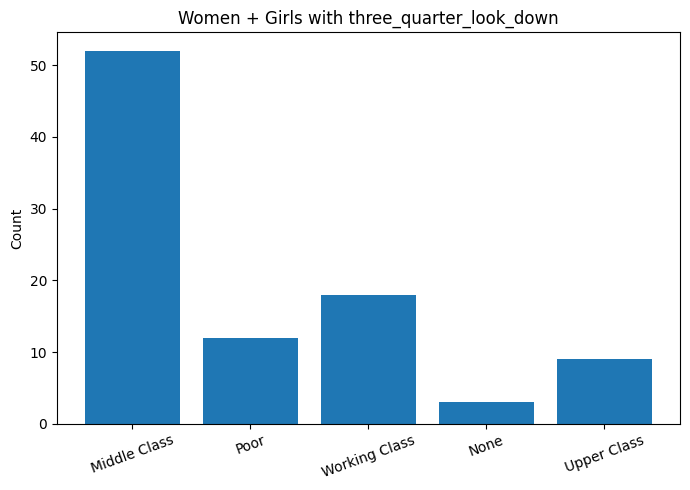

In [10]:
# grafico classi sociali

if women_counter:

    plt.figure(figsize=(7, 5))

    plt.bar(
        women_counter.keys(),
        women_counter.values()
    )

    plt.title(
        "Women + Girls with three_quarter_look_down"
    )

    plt.ylabel("Count")
    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.show()

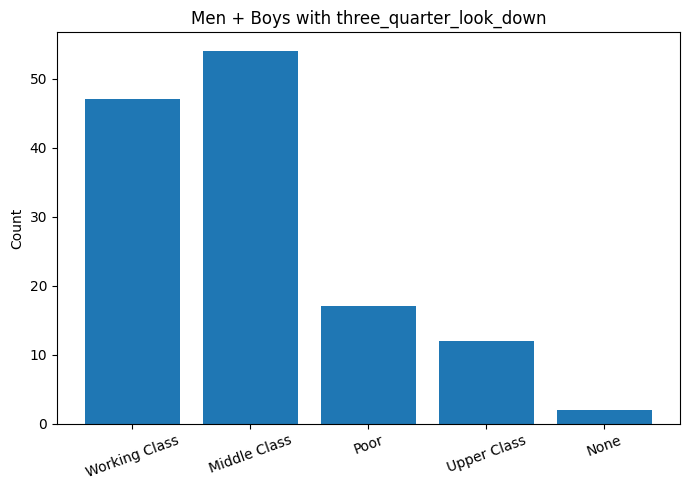

In [11]:
# come sopra ma per i personaggi maschili
if men_counter:

    plt.figure(figsize=(7, 5))

    plt.bar(
        men_counter.keys(),
        men_counter.values()
    )

    plt.title(
        "Men + Boys with three_quarter_look_down"
    )

    plt.ylabel("Count")
    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.show()


===== CLASSI SOCIALI FEMMINILI =====
Counter({'Middle Class': 315, 'Working Class': 89, 'Poor': 53, 'Upper Class': 41, 'None': 28, 'Middle': 3})

===== CLASSI SOCIALI MASCHILI =====
Counter({'Middle Class': 272, 'Working Class': 258, 'Poor': 78, 'None': 55, 'Upper Class': 52})


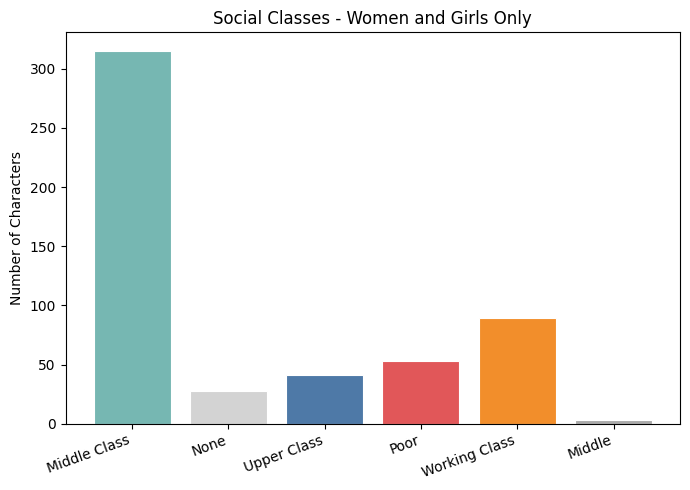

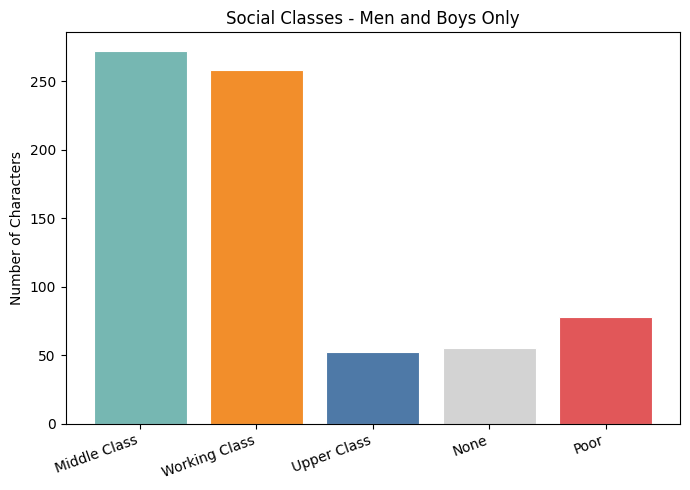

In [13]:
from collections import Counter
import matplotlib.pyplot as plt

# ==========================================
# PALETTE FISSA PER CLASSE SOCIALE
# ==========================================

CLASS_COLORS = {
    "Upper Class":   "#4e79a7",
    "Middle Class":  "#76b7b2",
    "Working Class": "#f28e2b",
    "Poor":          "#e15759",
    "Other":         "#bab0ac",
    "None":          "#d3d3d3",
}

# ==========================================
# DISTRIBUZIONE CLASSI SOCIALI
# ==========================================

female_social_classes = []
male_social_classes = []

for item in data:

    llm = item["llm_output"]

    if llm["illustration_present"] != "Yes":
        continue

    chars  = llm.get("characters", [])
    social = llm.get("social_class", [])

    if only_women_girls(chars):
        for char, soc in zip(chars, social):
            if char in ["Woman", "Girl"]:
                female_social_classes.append(soc)

    if only_men_boys(chars):
        for char, soc in zip(chars, social):
            if char in ["Man", "Boy"]:
                male_social_classes.append(soc)

# ==========================================
# CONTEGGI
# ==========================================

female_counter = Counter(female_social_classes)
male_counter   = Counter(male_social_classes)

print("\n===== CLASSI SOCIALI FEMMINILI =====")
print(female_counter)
print("\n===== CLASSI SOCIALI MASCHILI =====")
print(male_counter)

# ==========================================
# FUNZIONE DI PLOT RIUTILIZZABILE
# ==========================================

def plot_social_classes(counter, title):
    labels = list(counter.keys())
    values = list(counter.values())
    colors = [CLASS_COLORS.get(lbl, "#aaaaaa") for lbl in labels]

    plt.figure(figsize=(7, 5))
    plt.bar(labels, values, color=colors, edgecolor="white", linewidth=0.8)
    plt.title(title)
    plt.ylabel("Number of Characters")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

plot_social_classes(female_counter, "Social Classes - Women and Girls Only")
plot_social_classes(male_counter,   "Social Classes - Men and Boys Only")

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# ==========================================
# CONTEGGIO PERSONAGGI
# ==========================================

character_counter = Counter()

for item in data:

    llm = item["llm_output"]

    if llm["illustration_present"] != "Yes":
        continue

    chars = llm.get("characters", [])

    character_counter.update(chars)
    
character_counter = Counter(
    dict(character_counter.most_common())
)

print(character_counter)

Counter({'Man': 3193, 'Woman': 2101, 'Boy': 1928, 'Girl': 1515, 'Animal': 1149, 'None': 219, 'Mythical / Imaginary Being': 173, 'Other': 163, 'Animate Object': 113})


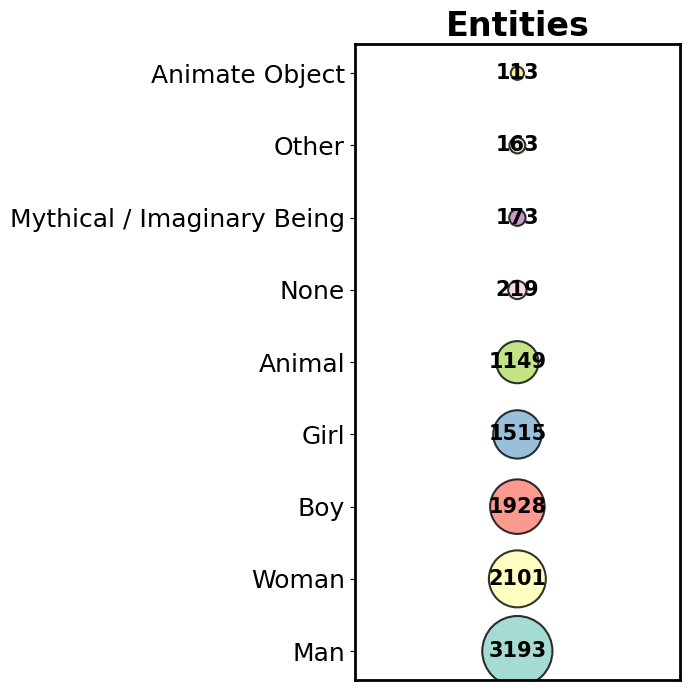

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# BUBBLE CHART PERSONAGGI
# ==========================================

labels = list(character_counter.keys())
values = list(character_counter.values())

# posizione verticale
y_pos = range(len(labels))

# tutte le bolle centrate
x_pos = [1] * len(labels)

# scala dimensioni bolle
sizes = [v * 0.8 for v in values]

# palette colori automatica
colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))

# grafico più stretto
plt.figure(figsize=(7, 7))

plt.scatter(
    x_pos,
    y_pos,
    s=sizes,
    c=colors,
    alpha=0.8,
    edgecolors='black',
    linewidths=1.5
)

# etichette categorie
plt.yticks(y_pos, labels, fontsize=18)

# valori dentro le bolle
for x, y, val in zip(x_pos, y_pos, values):

    plt.text(
        x,
        y,
        str(val),
        ha='center',
        va='center',
        fontsize=15,
        color='black',
        weight='bold'
    )

plt.title("Entities", fontsize=24, weight='bold')

# rimuove asse x
plt.xticks([])

# riduce larghezza visiva
plt.xlim(0.93, 1.07)

# bordo stile pulito
ax = plt.gca()

for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# CONTEGGIO CLASSI SOCIALI
# ==========================================

social_counter = Counter()

for item in data:

    llm = item["llm_output"]

    if llm["illustration_present"] != "Yes":
        continue

    social = llm.get("social_class", [])

    social_counter.update(social)

social_counter = Counter(
    dict(social_counter.most_common())
)

print(social_counter)

Counter({'Middle Class': 4027, 'None': 2468, 'Working Class': 2250, 'Upper Class': 1060, 'Poor': 731, 'Other': 4, 'Middle': 3})


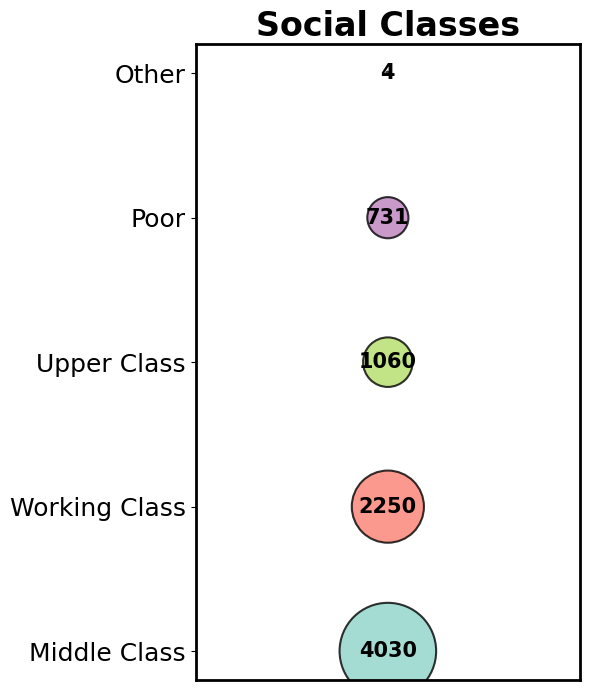

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# ── Rimozione artefatti ───────────────────────────────────────────────
SPURIOUS = {"n", "o", "e", "none"}
ALIASES  = {"Middle": "Middle Class"}

social_counter_clean = Counter()
for label, count in social_counter.items():
    s = str(label).strip()
    if s.lower() in SPURIOUS or s == "None":
        continue
    s = ALIASES.get(s, s)
    social_counter_clean[s] += count

# ==========================================
# BUBBLE CHART CLASSI SOCIALI
# ==========================================

labels = list(social_counter_clean.keys())
values = list(social_counter_clean.values())

y_pos = range(len(labels))
x_pos = [1] * len(labels)

sizes = [v * 1.2 for v in values]

colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))

plt.figure(figsize=(6, 7))

plt.scatter(
    x_pos,
    y_pos,
    s=sizes,
    c=colors,
    alpha=0.8,
    edgecolors='black',
    linewidths=1.5
)

plt.yticks(y_pos, labels, fontsize=18)

for x, y, val in zip(x_pos, y_pos, values):
    plt.text(
        x, y, str(val),
        ha='center', va='center',
        fontsize=15, color='black', weight='bold'
    )

plt.title("Social Classes", fontsize=24, weight='bold')
plt.xticks([])
plt.xlim(0.93, 1.07)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()

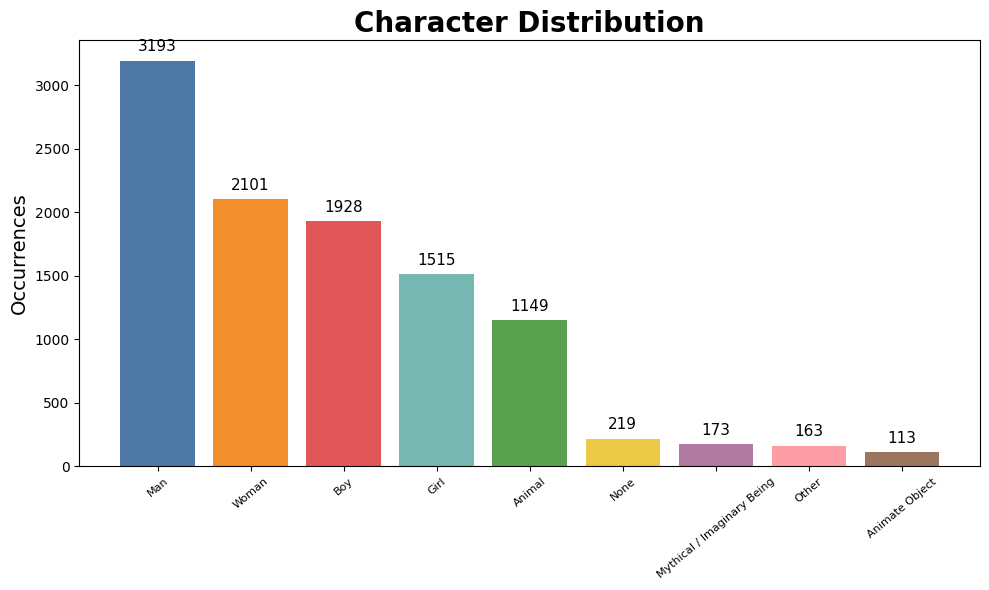

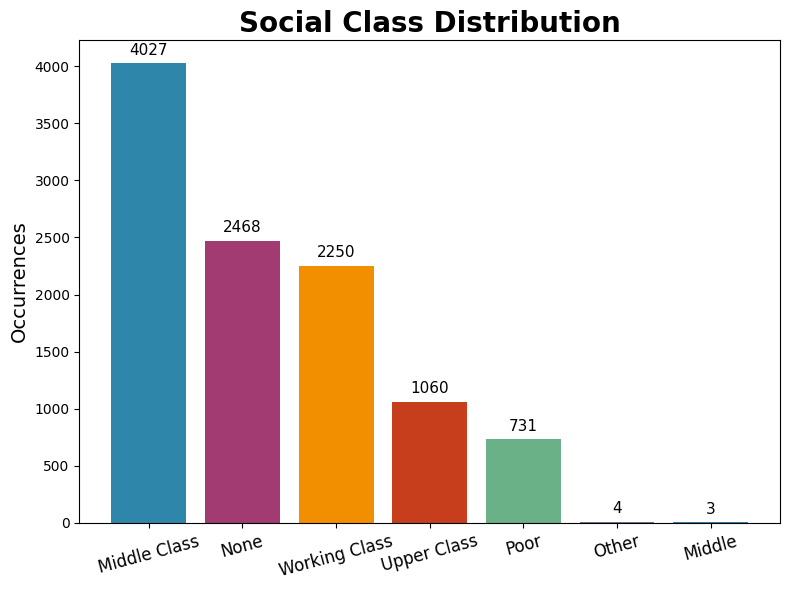

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# ==========================================
# CONTEGGIO PERSONAGGI
# ==========================================

character_counter = Counter()

for item in data:

    llm = item["llm_output"]

    if llm["illustration_present"] != "Yes":
        continue

    chars = llm.get("characters", [])

    character_counter.update(chars)

# ordinamento decrescente
character_counter = dict(
    sorted(
        character_counter.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

# ==========================================
# GRAFICO PERSONAGGI
# ==========================================

labels = list(character_counter.keys())
values = list(character_counter.values())

# un colore diverso per ogni categoria
colors = [
    "#4E79A7",
    "#F28E2B",
    "#E15759",
    "#76B7B2",
    "#59A14F",
    "#EDC948",
    "#B07AA1",
    "#FF9DA7",
    "#9C755F",
    "#BAB0AC"
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    labels,
    values,
    color=colors[:len(labels)]
)

# valori sopra le barre
for bar, value in zip(bars, values):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        str(value),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title(
    "Character Distribution",
    fontsize=20,
    weight='bold'
)

plt.ylabel("Occurrences", fontsize=14)

plt.xticks(rotation=40, fontsize=8)

plt.tight_layout()
plt.show()

# ==========================================
# CONTEGGIO CLASSI SOCIALI
# ==========================================

social_counter = Counter()

for item in data:

    llm = item["llm_output"]

    if llm["illustration_present"] != "Yes":
        continue

    social = llm.get("social_class", [])

    social_counter.update(social)

# ordinamento decrescente
social_counter = dict(
    sorted(
        social_counter.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

# ==========================================
# GRAFICO CLASSI SOCIALI
# ==========================================

labels = list(social_counter.keys())
values = list(social_counter.values())

colors = [
    "#2E86AB",
    "#A23B72",
    "#F18F01",
    "#C73E1D",
    "#6AB187",
    "#7B6D8D"
]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    labels,
    values,
    color=colors[:len(labels)]
)

# valori sopra le barre
for bar, value in zip(bars, values):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        str(value),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title(
    "Social Class Distribution",
    fontsize=20,
    weight='bold'
)

plt.ylabel("Occurrences", fontsize=14)

plt.xticks(rotation=15, fontsize=12)

plt.tight_layout()
plt.show()

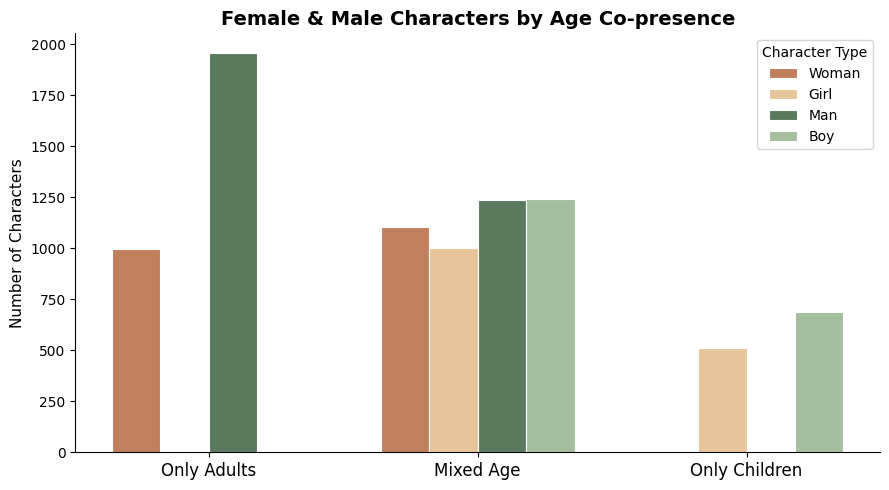

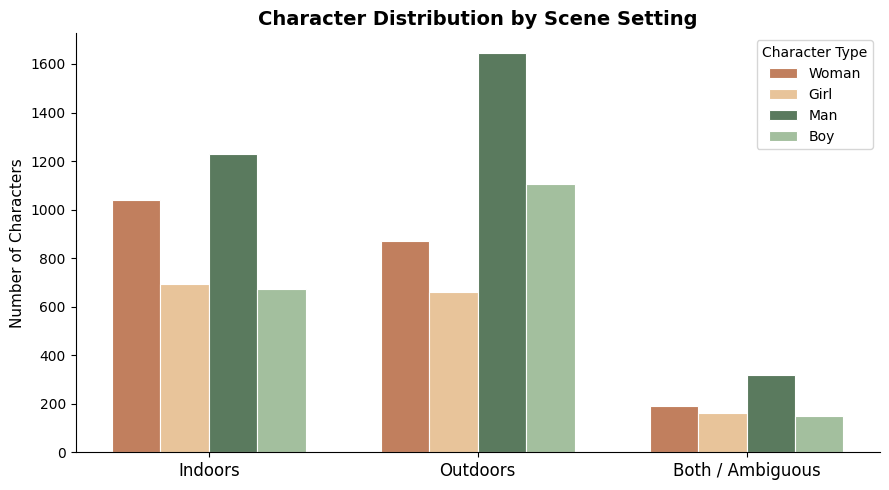

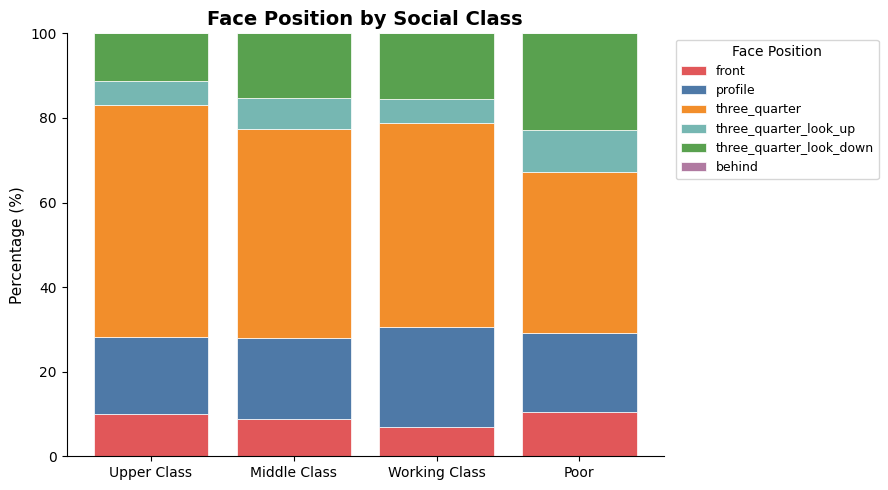

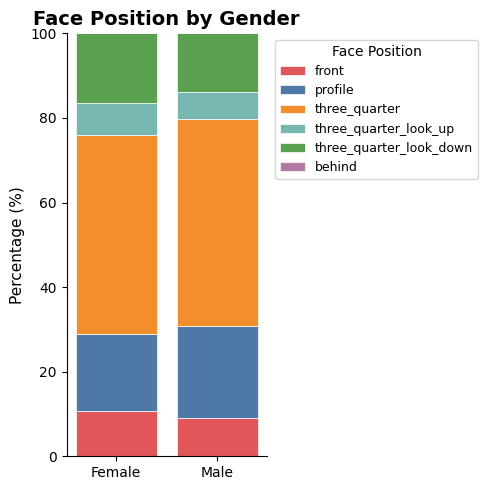

In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter, defaultdict

with open("/Users/deniseatzori/Library/Mobile Documents/com~apple~CloudDocs/ENC-PSL/Memoire/Github_tesi/Results/MLLM_annotation/llm_annotations.json") as f:
    data = json.load(f)

# ──────────────────────────────────────────────
# PALETTE E COSTANTI
# ──────────────────────────────────────────────

SPURIOUS = {"n", "o", "e", "none"}
ALIASES  = {"Middle": "Middle Class"}

GENDER_COLORS = {
    "Woman": "#c17f5e",   # terracotta
    "Girl":  "#e8c49a",   # sabbia chiaro
    "Man":   "#5a7a5e",   # verde oliva scuro
    "Boy":   "#a3bf9e",   # verde salvia
}

CLASS_COLORS = {
    "Upper Class":   "#4e79a7",
    "Middle Class":  "#76b7b2",
    "Working Class": "#f28e2b",
    "Poor":          "#e15759",
    "Other":         "#bab0ac",
}

SCENE_COLORS = {
    "Indoors":          "#7fc97f",
    "Outdoors":         "#beaed4",
    "Both / Ambiguous": "#fdc086",
    "None":             "#d3d3d3",
}

FP_COLORS = {
    "front":                 "#e15759",
    "profile":               "#4e79a7",
    "three_quarter":         "#f28e2b",
    "three_quarter_look_up": "#76b7b2",
    "three_quarter_look_down":"#59a14f",
    "behind":                "#b07aa1",
    "None":                  "#d3d3d3",
}

GENDER_TYPES = ["Woman", "Girl", "Man", "Boy"]


def clean_label(s):
    s = str(s).strip()
    if s.lower() in SPURIOUS or s == "None":
        return None
    return ALIASES.get(s, s)


# ──────────────────────────────────────────────
# RACCOLTA DATI
# ──────────────────────────────────────────────

# 1. Co-presence per tipo di età (mix M/F per illustrazione)
#    Categorie: "Only Adults", "Only Children", "Mixed Age"
#    Per ogni categoria, conta Woman / Girl / Man / Boy

age_gender = defaultdict(Counter)   # age_category -> Counter(character)

# 2. Personaggi per scene_setting
scene_gender = defaultdict(Counter) # scene -> Counter(character)

# 3. faces_position per social_class e genere
fp_class  = defaultdict(Counter)    # social_class -> Counter(face_pos)
fp_gender = defaultdict(Counter)    # gender       -> Counter(face_pos)

for item in data:
    llm = item.get("llm_output", {})
    if llm.get("illustration_present") != "Yes":
        continue

    chars  = [str(c).strip() for c in llm.get("characters") or []]
    social = [clean_label(s) for s in llm.get("social_class") or []]
    faces  = [str(f).strip() for f in llm.get("faces_position") or []]
    scene  = str(llm.get("scene_setting", "")).strip()
    if scene == "Ambiguous":
        scene = "Both / Ambiguous"

    # ── età per illustrazione ──────────────────
    has_adult   = any(c in ("Woman", "Man")  for c in chars)
    has_child   = any(c in ("Girl",  "Boy")  for c in chars)

    if has_adult and has_child:
        age_cat = "Mixed Age"
    elif has_child:
        age_cat = "Only Children"
    else:
        age_cat = "Only Adults"

    for c in chars:
        if c in GENDER_TYPES:
            age_gender[age_cat][c] += 1

    # ── scene_setting ──────────────────────────
    for c in chars:
        if c in GENDER_TYPES:
            scene_gender[scene][c] += 1

    # ── faces_position per class e gender ──────
    for c, s, f in zip(chars, social, faces):
        if f.lower() in SPURIOUS or f == "None":
            continue
        if s:
            fp_class[s][f] += 1
        if c in GENDER_TYPES:
            gender_label = "Female" if c in ("Woman", "Girl") else "Male"
            fp_gender[gender_label][f] += 1


# ──────────────────────────────────────────────
# PLOT 1 – CO-PRESENZA PER ETÀ
# ──────────────────────────────────────────────

age_cats   = ["Only Adults", "Mixed Age", "Only Children"]
char_types = ["Woman", "Girl", "Man", "Boy"]
x          = np.arange(len(age_cats))
bar_w      = 0.18

fig, ax = plt.subplots(figsize=(9, 5))

for i, char in enumerate(char_types):
    counts = [age_gender[cat][char] for cat in age_cats]
    ax.bar(x + i * bar_w, counts, bar_w,
           label=char, color=GENDER_COLORS[char],
           edgecolor="white", linewidth=0.8)

ax.set_xticks(x + bar_w * 1.5)
ax.set_xticklabels(age_cats, fontsize=12)
ax.set_ylabel("Number of Characters", fontsize=11)
ax.set_title("Female & Male Characters by Age Co-presence", fontsize=14, weight="bold")
ax.legend(title="Character Type", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


# ──────────────────────────────────────────────
# PLOT 2 – DISTRIBUZIONE PER SCENE_SETTING
# ──────────────────────────────────────────────

scenes = [s for s in scene_gender if s not in ("", "None")]
x      = np.arange(len(scenes))
bar_w  = 0.18

fig, ax = plt.subplots(figsize=(9, 5))

for i, char in enumerate(char_types):
    counts = [scene_gender[s][char] for s in scenes]
    ax.bar(x + i * bar_w, counts, bar_w,
           label=char, color=GENDER_COLORS[char],
           edgecolor="white", linewidth=0.8)

ax.set_xticks(x + bar_w * 1.5)
ax.set_xticklabels(scenes, fontsize=12)
ax.set_ylabel("Number of Characters", fontsize=11)
ax.set_title("Character Distribution by Scene Setting", fontsize=14, weight="bold")
ax.legend(title="Character Type", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


# ──────────────────────────────────────────────
# PLOT 3a – FACES_POSITION PER CLASSE SOCIALE
# (stacked bar normalizzato al 100%)
# ──────────────────────────────────────────────

fp_labels   = [k for k in FP_COLORS if k != "None"]
soc_classes = [c for c in ("Upper Class", "Middle Class", "Working Class", "Poor")
               if c in fp_class]

fig, ax = plt.subplots(figsize=(9, 5))
bottoms = np.zeros(len(soc_classes))

for fp in fp_labels:
    raw    = np.array([fp_class[c][fp] for c in soc_classes], dtype=float)
    totals = np.array([sum(fp_class[c].values()) for c in soc_classes], dtype=float)
    totals[totals == 0] = 1
    pct = raw / totals * 100
    ax.bar(soc_classes, pct, bottom=bottoms,
           label=fp, color=FP_COLORS[fp],
           edgecolor="white", linewidth=0.5)
    bottoms += pct

ax.set_ylabel("Percentage (%)", fontsize=11)
ax.set_title("Face Position by Social Class", fontsize=14, weight="bold")
ax.set_ylim(0, 100)
ax.legend(title="Face Position", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


# ──────────────────────────────────────────────
# PLOT 3b – FACES_POSITION PER GENERE
# (stacked bar normalizzato al 100%)
# ──────────────────────────────────────────────

genders = ["Female", "Male"]

fig, ax = plt.subplots(figsize=(5, 5))
bottoms = np.zeros(len(genders))

for fp in fp_labels:
    raw    = np.array([fp_gender[g][fp] for g in genders], dtype=float)
    totals = np.array([sum(fp_gender[g].values()) for g in genders], dtype=float)
    totals[totals == 0] = 1
    pct = raw / totals * 100
    ax.bar(genders, pct, bottom=bottoms,
           label=fp, color=FP_COLORS[fp],
           edgecolor="white", linewidth=0.5)
    bottoms += pct

ax.set_ylabel("Percentage (%)", fontsize=11)
ax.set_title("Face Position by Gender", fontsize=14, weight="bold")
ax.set_ylim(0, 100)
ax.legend(title="Face Position", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
① RAPPORTO MASCHI / FEMMINE NEL TEMPO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Decade       Woman    Girl     Man     Boy      F%      M%
1840s           82     112     153      80   45.4%   54.6%
1860s          292     183     537     391   33.9%   66.1%
1870s          361     267     474     283   45.3%   54.7%
1880s          661     395    1062     671   37.9%   62.1%
1890s          297     248     459     188   45.7%   54.3%
1900s          239     180     297     146   48.6%   51.4%
1910s           88      57     108      57   46.8%   53.2%
1920s           60      61      69      77   45.3%   54.7%


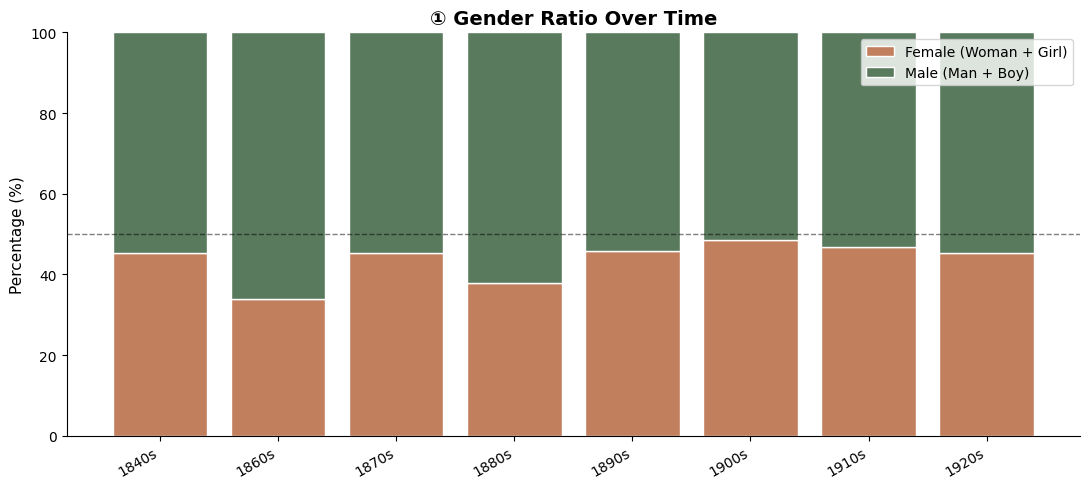


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
② DISTRIBUZIONE CLASSI SOCIALI NEL TEMPO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


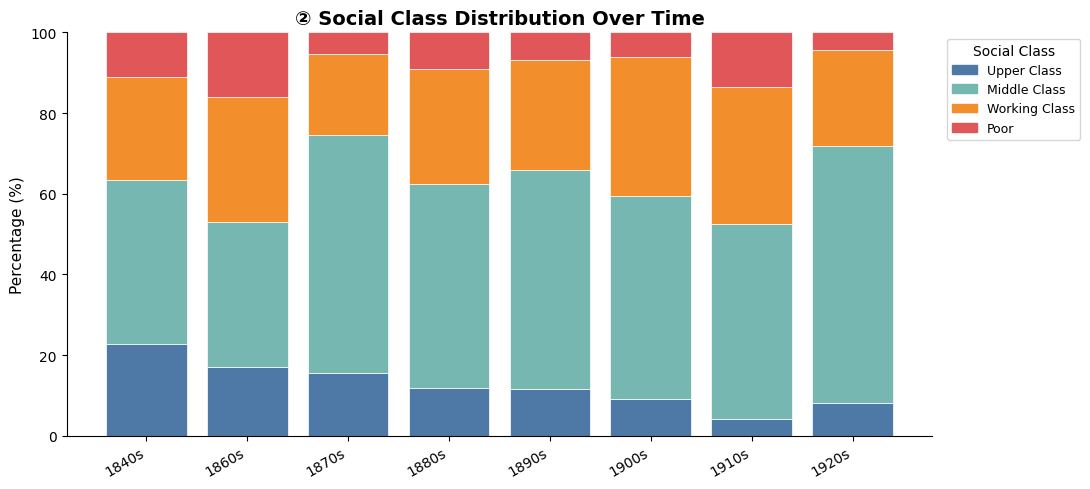


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
③ EMOTIONAL INTENSITY MEDIA NEL TEMPO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Decade       Mean EI     Std      N
1840s           2.04    0.79    242
1860s           2.40    0.93    677
1870s           1.99    0.88    708
1880s           2.07    0.89   1296
1890s           1.91    0.84    689
1900s           2.16    1.03    399
1910s           2.22    0.78    109
1920s           2.41    0.90    141


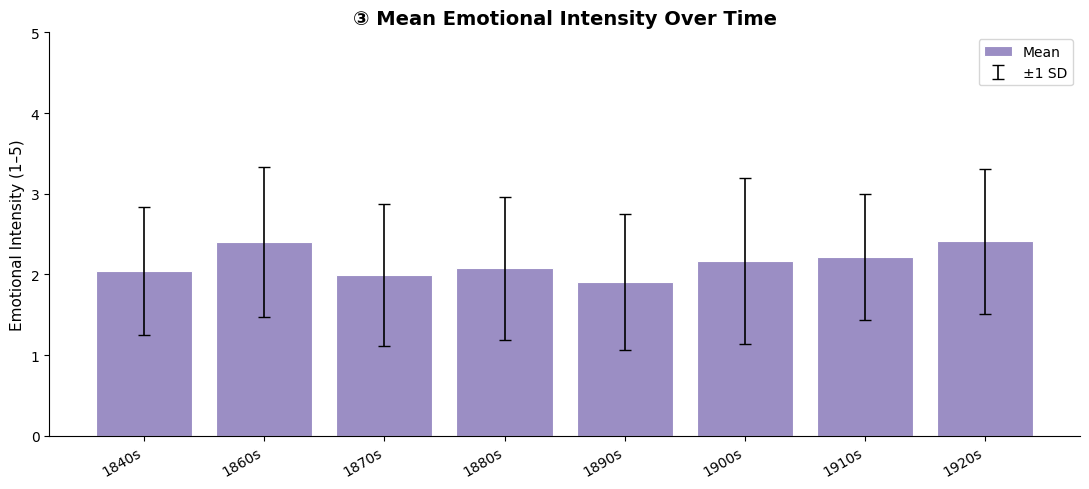


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
④ FACES_POSITION PER GENERE NEL TEMPO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


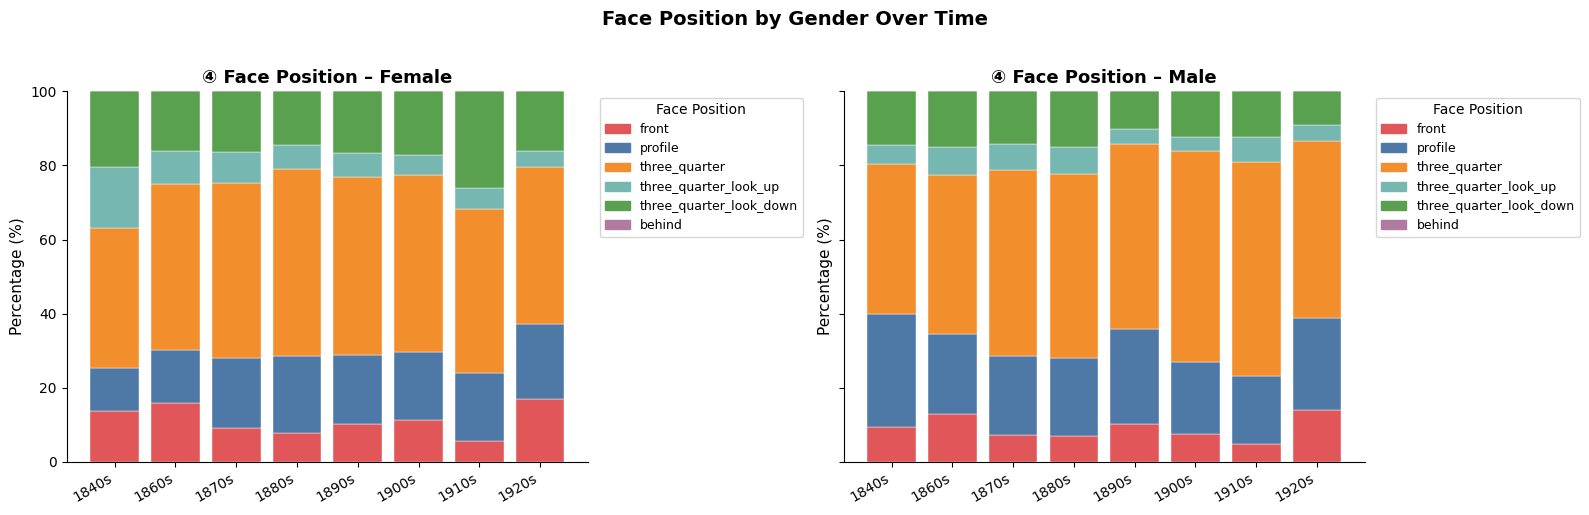


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⑤ GIOCATTOLI PER GENERE E NEL TEMPO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


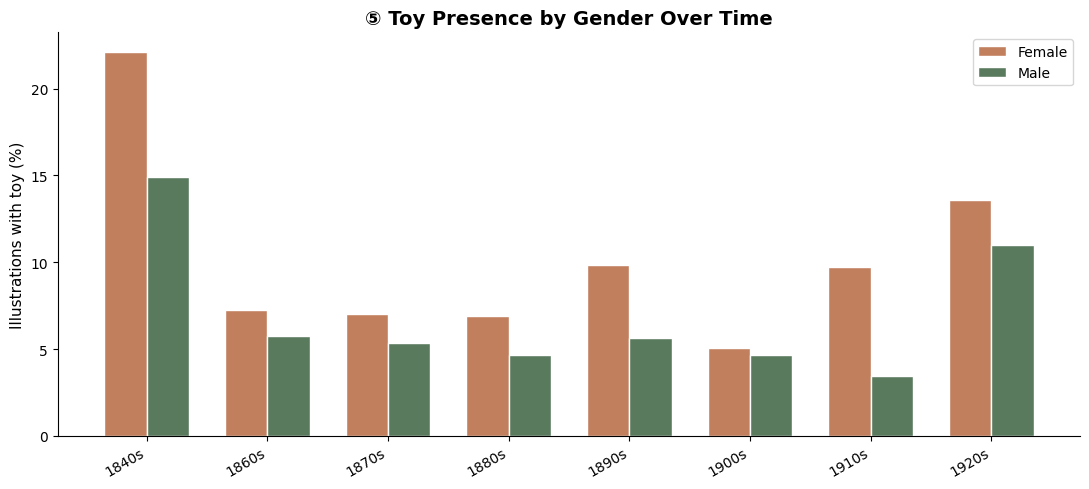


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⑥ CLASSE SOCIALE PER GENERE NELLA STESSA ILLUSTRAZIONE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


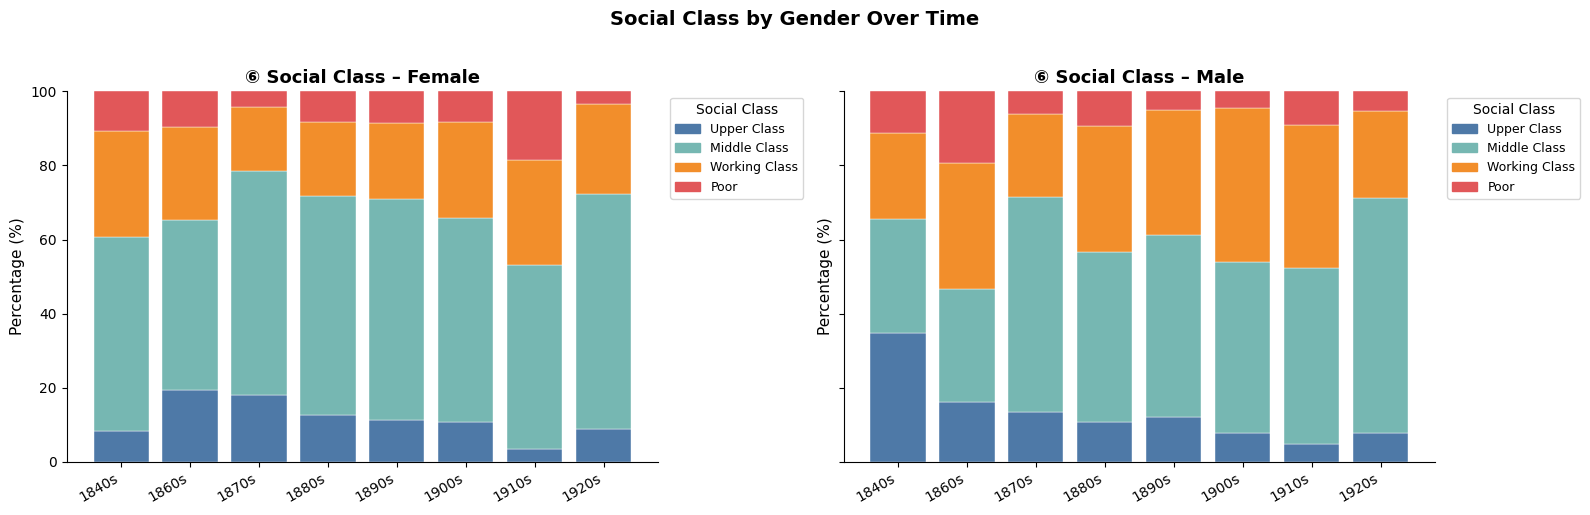


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⑦ SCENE_SETTING PER GENERE NEL TEMPO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


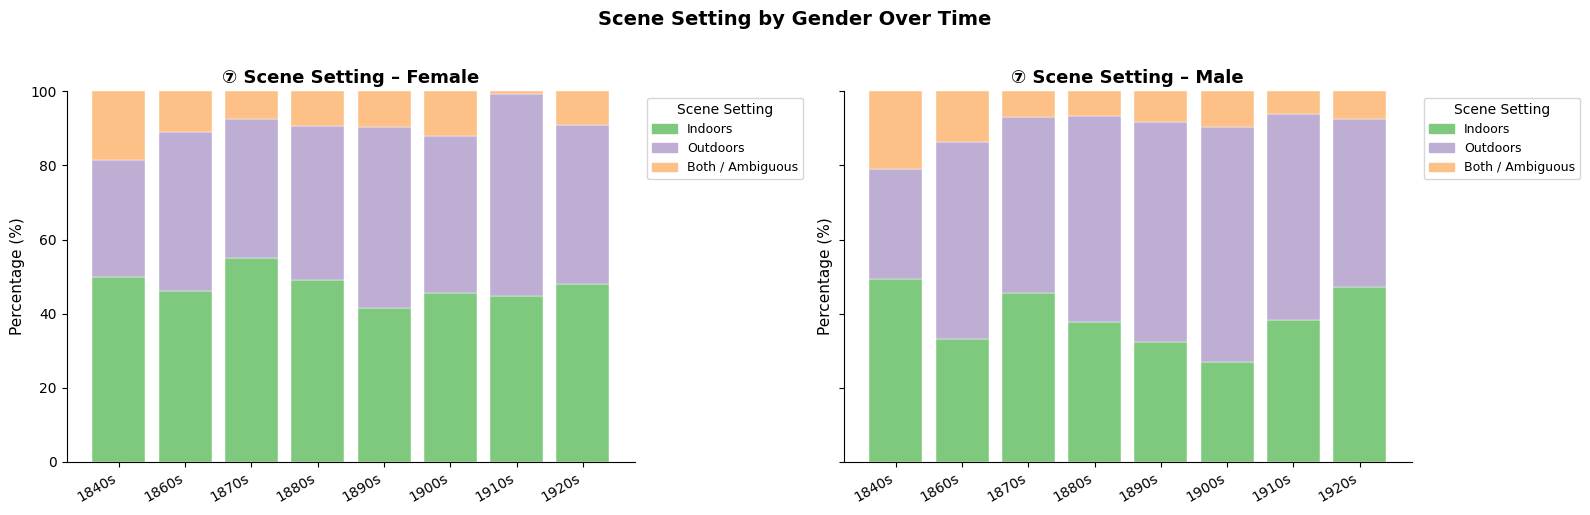


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⑧ CO-OCCORRENZE DI PERSONAGGI (top 15 coppie)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Coppia                          Conteggio
  Man + Man                          1639
  Man + Woman                        1580
  Boy + Man                          1152
  Girl + Woman                        884
  Boy + Boy                           853
  Boy + Woman                         763
  Boy + Girl                          703
  Girl + Man                          655
  Woman + Woman                       427
  Girl + Girl                         398


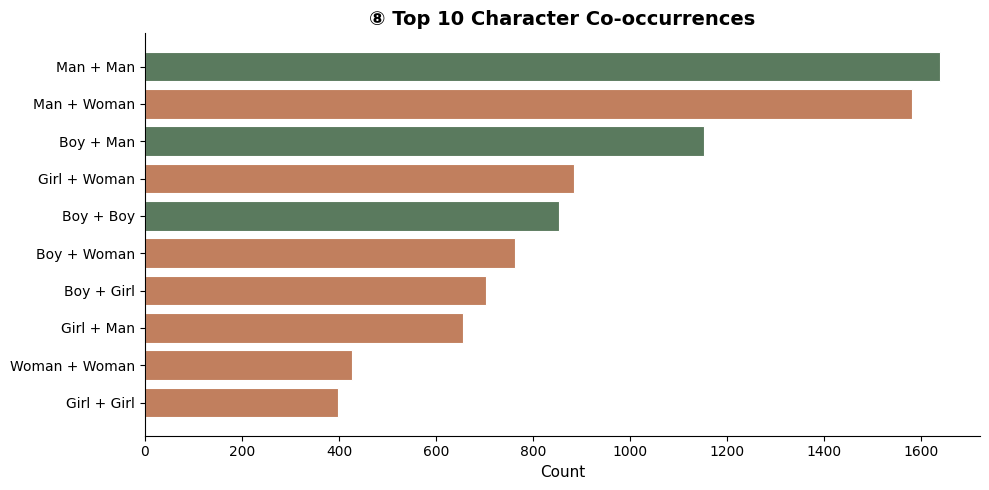


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⑨ SCENE_SETTING × EMOTIONAL INTENSITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Scene                   Mean EI     Std       N
  Indoors                  2.14    0.81    1586
  Outdoors                 2.14    0.98    2124
  Both / Ambiguous         1.89    0.87     613


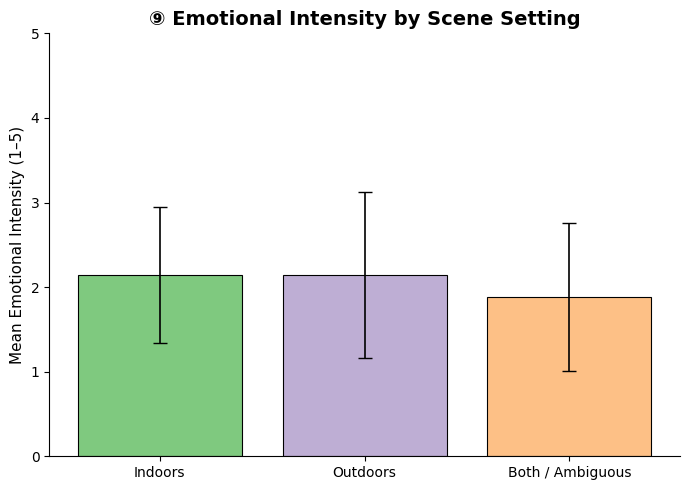

In [17]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter, defaultdict
from itertools import combinations

with open("/Users/deniseatzori/Library/Mobile Documents/com~apple~CloudDocs/ENC-PSL/Memoire/Github_tesi/Results/MLLM_annotation/llm_annotations.json") as f:
    data = json.load(f)

# ══════════════════════════════════════════════════════════════════
# PALETTE E COSTANTI
# ══════════════════════════════════════════════════════════════════

SPURIOUS = {"n", "o", "e", "none"}
ALIASES  = {"Middle": "Middle Class", "Ambiguous": "Both / Ambiguous"}

GENDER_COLORS = {
    "Woman": "#c17f5e",
    "Girl":  "#e8c49a",
    "Man":   "#5a7a5e",
    "Boy":   "#a3bf9e",
}
GENDER_AGG_COLORS = {"Female": "#c17f5e", "Male": "#5a7a5e"}

CLASS_COLORS = {
    "Upper Class":   "#4e79a7",
    "Middle Class":  "#76b7b2",
    "Working Class": "#f28e2b",
    "Poor":          "#e15759",
    "Other":         "#bab0ac",
}
CLASS_ORDER = ["Upper Class", "Middle Class", "Working Class", "Poor"]

SCENE_COLORS = {
    "Indoors":          "#7fc97f",
    "Outdoors":         "#beaed4",
    "Both / Ambiguous": "#fdc086",
}

FP_COLORS = {
    "front":                  "#e15759",
    "profile":                "#4e79a7",
    "three_quarter":          "#f28e2b",
    "three_quarter_look_up":  "#76b7b2",
    "three_quarter_look_down":"#59a14f",
    "behind":                 "#b07aa1",
}

GENDER_TYPES  = ["Woman", "Girl", "Man", "Boy"]
DECADE_LABELS = {
    1830: "1830s", 1840: "1840s", 1850: "1850s", 1860: "1860s",
    1870: "1870s", 1880: "1880s", 1890: "1890s", 1900: "1900s",
    1910: "1910s", 1920: "1920s", 1930: "1930s", 1940: "1940s",
    1960: "1960s",
}

# Decenni con almeno 50 illustrazioni per analisi temporali affidabili
MIN_ILLUS = 50


# ══════════════════════════════════════════════════════════════════
# UTILITÀ
# ══════════════════════════════════════════════════════════════════

def clean_label(s, aliases=ALIASES):
    s = str(s).strip()
    if s.lower() in SPURIOUS or s in ("None", ""):
        return None
    return aliases.get(s, s)

def extract_decade(subfolder):
    m = re.match(r"^(\d{4})", subfolder)
    return (int(m.group(1)) // 10) * 10 if m else None

def pct_stack(counter, keys):
    """Ritorna array percentuali per stacked bar."""
    total = sum(counter.get(k, 0) for k in keys)
    if total == 0:
        return [0.0] * len(keys)
    return [counter.get(k, 0) / total * 100 for k in keys]

def add_legend_outside(ax, colors_dict, title=""):
    patches = [plt.Rectangle((0,0),1,1, color=c, label=l)
               for l, c in colors_dict.items()]
    ax.legend(handles=patches, title=title,
              bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

def decade_axis(ax, decades):
    ax.set_xticks(range(len(decades)))
    ax.set_xticklabels([DECADE_LABELS.get(d, str(d)) for d in decades],
                       rotation=30, ha="right", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)


# ══════════════════════════════════════════════════════════════════
# RACCOLTA DATI PRINCIPALE
# ══════════════════════════════════════════════════════════════════

# Strutture per decade
by_decade = defaultdict(list)   # decade -> lista di llm_output

for item in data:
    llm = item.get("llm_output", {})
    if llm.get("illustration_present") != "Yes":
        continue
    decade = extract_decade(item.get("subfolder", ""))
    if decade is not None:
        by_decade[decade].append(llm)

all_decades   = sorted(by_decade.keys())
valid_decades = [d for d in all_decades if len(by_decade[d]) >= MIN_ILLUS]


# ══════════════════════════════════════════════════════════════════
# ① RAPPORTO MASCHI / FEMMINE NEL TEMPO
# ══════════════════════════════════════════════════════════════════

print("━" * 60)
print("① RAPPORTO MASCHI / FEMMINE NEL TEMPO")
print("━" * 60)

decade_gender_count = {}
for d in valid_decades:
    cnt = Counter()
    for llm in by_decade[d]:
        for c in llm.get("characters") or []:
            c = str(c).strip()
            if c in GENDER_TYPES:
                cnt[c] += 1
    decade_gender_count[d] = cnt

# stampa
print(f"{'Decade':<10} {'Woman':>7} {'Girl':>7} {'Man':>7} {'Boy':>7} {'F%':>7} {'M%':>7}")
for d in valid_decades:
    cnt = decade_gender_count[d]
    f = cnt["Woman"] + cnt["Girl"]
    m = cnt["Man"]   + cnt["Boy"]
    tot = f + m or 1
    print(f"{DECADE_LABELS[d]:<10} {cnt['Woman']:>7} {cnt['Girl']:>7} "
          f"{cnt['Man']:>7} {cnt['Boy']:>7} {f/tot*100:>6.1f}% {m/tot*100:>6.1f}%")

# grafico: % femminile vs maschile per decennio
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(valid_decades))
female_pct = []
male_pct   = []
for d in valid_decades:
    cnt = decade_gender_count[d]
    f   = cnt["Woman"] + cnt["Girl"]
    m   = cnt["Man"]   + cnt["Boy"]
    tot = f + m or 1
    female_pct.append(f / tot * 100)
    male_pct.append(m / tot * 100)

ax.bar(x, female_pct, label="Female (Woman + Girl)",
       color=GENDER_AGG_COLORS["Female"], edgecolor="white")
ax.bar(x, male_pct, bottom=female_pct, label="Male (Man + Boy)",
       color=GENDER_AGG_COLORS["Male"], edgecolor="white")
ax.axhline(50, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.set_ylabel("Percentage (%)", fontsize=11)
ax.set_ylim(0, 100)
ax.set_title("① Gender Ratio Over Time", fontsize=14, weight="bold")
ax.legend(fontsize=10)
decade_axis(ax, valid_decades)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════
# ② DISTRIBUZIONE CLASSI SOCIALI NEL TEMPO
# ══════════════════════════════════════════════════════════════════

print("\n" + "━" * 60)
print("② DISTRIBUZIONE CLASSI SOCIALI NEL TEMPO")
print("━" * 60)

decade_class = {}
for d in valid_decades:
    cnt = Counter()
    for llm in by_decade[d]:
        for s in llm.get("social_class") or []:
            s = clean_label(s)
            if s and s in CLASS_ORDER:
                cnt[s] += 1
    decade_class[d] = cnt

fig, ax = plt.subplots(figsize=(11, 5))
x       = np.arange(len(valid_decades))
bottoms = np.zeros(len(valid_decades))

for cls in CLASS_ORDER:
    pcts = np.array([pct_stack(decade_class[d], CLASS_ORDER)[CLASS_ORDER.index(cls)]
                     for d in valid_decades])
    ax.bar(x, pcts, bottom=bottoms, label=cls,
           color=CLASS_COLORS[cls], edgecolor="white", linewidth=0.5)
    bottoms += pcts

ax.set_ylabel("Percentage (%)", fontsize=11)
ax.set_ylim(0, 100)
ax.set_title("② Social Class Distribution Over Time", fontsize=14, weight="bold")
add_legend_outside(ax, {c: CLASS_COLORS[c] for c in CLASS_ORDER}, title="Social Class")
decade_axis(ax, valid_decades)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════
# ③ EMOTIONAL INTENSITY MEDIA NEL TEMPO
# ══════════════════════════════════════════════════════════════════

print("\n" + "━" * 60)
print("③ EMOTIONAL INTENSITY MEDIA NEL TEMPO")
print("━" * 60)

decade_ei = {}
for d in valid_decades:
    vals = []
    for llm in by_decade[d]:
        ei = llm.get("emotional_intensity")
        try:
            vals.append(float(ei))
        except (TypeError, ValueError):
            pass
    decade_ei[d] = vals

print(f"{'Decade':<10} {'Mean EI':>9} {'Std':>7} {'N':>6}")
for d in valid_decades:
    v = decade_ei[d]
    print(f"{DECADE_LABELS[d]:<10} {np.mean(v):>9.2f} {np.std(v):>7.2f} {len(v):>6}")

fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(valid_decades))
means = [np.mean(decade_ei[d]) for d in valid_decades]
stds  = [np.std(decade_ei[d])  for d in valid_decades]
ax.bar(x, means, color="#9b8ec4", edgecolor="white", linewidth=0.8, label="Mean")
ax.errorbar(x, means, yerr=stds, fmt="none", color="black",
            capsize=4, linewidth=1.2, label="±1 SD")
ax.set_ylabel("Emotional Intensity (1–5)", fontsize=11)
ax.set_ylim(0, 5)
ax.set_title("③ Mean Emotional Intensity Over Time", fontsize=14, weight="bold")
ax.legend(fontsize=10)
decade_axis(ax, valid_decades)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════
# ④ FACES_POSITION PER GENERE NEL TEMPO
# ══════════════════════════════════════════════════════════════════

print("\n" + "━" * 60)
print("④ FACES_POSITION PER GENERE NEL TEMPO")
print("━" * 60)

fp_keys = list(FP_COLORS.keys())
decade_fp_gender = {g: {d: Counter() for d in valid_decades}
                    for g in ("Female", "Male")}

for d in valid_decades:
    for llm in by_decade[d]:
        chars = llm.get("characters") or []
        faces = llm.get("faces_position") or []
        for c, f in zip(chars, faces):
            c = str(c).strip()
            f = str(f).strip()
            if f.lower() in SPURIOUS or f == "None":
                continue
            if c in ("Woman", "Girl"):
                decade_fp_gender["Female"][d][f] += 1
            elif c in ("Man", "Boy"):
                decade_fp_gender["Male"][d][f] += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, gender in zip(axes, ("Female", "Male")):
    x       = np.arange(len(valid_decades))
    bottoms = np.zeros(len(valid_decades))
    for fp in fp_keys:
        pcts = np.array([pct_stack(decade_fp_gender[gender][d], fp_keys)[fp_keys.index(fp)]
                         for d in valid_decades])
        ax.bar(x, pcts, bottom=bottoms, label=fp,
               color=FP_COLORS[fp], edgecolor="white", linewidth=0.3)
        bottoms += pcts
    ax.set_title(f"④ Face Position – {gender}", fontsize=13, weight="bold")
    ax.set_ylabel("Percentage (%)", fontsize=11)
    ax.set_ylim(0, 100)
    add_legend_outside(ax, FP_COLORS, title="Face Position")
    decade_axis(ax, valid_decades)

plt.suptitle("Face Position by Gender Over Time", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════
# ⑤ GIOCATTOLI PER GENERE E NEL TEMPO
# ══════════════════════════════════════════════════════════════════

print("\n" + "━" * 60)
print("⑤ GIOCATTOLI PER GENERE E NEL TEMPO")
print("━" * 60)

TOY_SPURIOUS = {"none", "n", "o", "e"}

decade_toy_present = {g: [] for g in ("Female", "Male")}

for d in valid_decades:
    for gender in ("Female", "Male"):
        target = ("Woman", "Girl") if gender == "Female" else ("Man", "Boy")
        n_illus_with_gender = 0
        n_with_toy          = 0
        for llm in by_decade[d]:
            chars = [str(c).strip() for c in (llm.get("characters") or [])]
            toys  = [str(t).strip().lower() for t in (llm.get("toy") or [])]
            has_target = any(c in target for c in chars)
            has_toy    = any(t not in TOY_SPURIOUS and t != "none" for t in toys)
            if has_target:
                n_illus_with_gender += 1
                if has_toy:
                    n_with_toy += 1
        pct = n_with_toy / n_illus_with_gender * 100 if n_illus_with_gender else 0
        decade_toy_present[gender].append(pct)

fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(valid_decades))
w     = 0.35
ax.bar(x - w/2, decade_toy_present["Female"], w,
       label="Female", color=GENDER_AGG_COLORS["Female"], edgecolor="white")
ax.bar(x + w/2, decade_toy_present["Male"],   w,
       label="Male",   color=GENDER_AGG_COLORS["Male"],   edgecolor="white")
ax.set_ylabel("Illustrations with toy (%)", fontsize=11)
ax.set_title("⑤ Toy Presence by Gender Over Time", fontsize=14, weight="bold")
ax.legend(fontsize=10)
decade_axis(ax, valid_decades)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════
# ⑥ CLASSE SOCIALE: DISPARITÀ M/F NELLA STESSA ILLUSTRAZIONE
# ══════════════════════════════════════════════════════════════════

print("\n" + "━" * 60)
print("⑥ CLASSE SOCIALE PER GENERE NELLA STESSA ILLUSTRAZIONE")
print("━" * 60)

decade_class_gender = {g: {d: Counter() for d in valid_decades}
                       for g in ("Female", "Male")}

for d in valid_decades:
    for llm in by_decade[d]:
        chars  = llm.get("characters") or []
        social = llm.get("social_class") or []
        for c, s in zip(chars, social):
            c = str(c).strip()
            s = clean_label(s)
            if s not in CLASS_ORDER:
                continue
            if c in ("Woman", "Girl"):
                decade_class_gender["Female"][d][s] += 1
            elif c in ("Man", "Boy"):
                decade_class_gender["Male"][d][s]   += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, gender in zip(axes, ("Female", "Male")):
    x       = np.arange(len(valid_decades))
    bottoms = np.zeros(len(valid_decades))
    for cls in CLASS_ORDER:
        pcts = np.array([pct_stack(decade_class_gender[gender][d], CLASS_ORDER)[CLASS_ORDER.index(cls)]
                         for d in valid_decades])
        ax.bar(x, pcts, bottom=bottoms, label=cls,
               color=CLASS_COLORS[cls], edgecolor="white", linewidth=0.3)
        bottoms += pcts
    ax.set_title(f"⑥ Social Class – {gender}", fontsize=13, weight="bold")
    ax.set_ylabel("Percentage (%)", fontsize=11)
    ax.set_ylim(0, 100)
    add_legend_outside(ax, {c: CLASS_COLORS[c] for c in CLASS_ORDER}, "Social Class")
    decade_axis(ax, valid_decades)

plt.suptitle("Social Class by Gender Over Time", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════
# ⑦ SCENE_SETTING PER GENERE NEL TEMPO
# ══════════════════════════════════════════════════════════════════

print("\n" + "━" * 60)
print("⑦ SCENE_SETTING PER GENERE NEL TEMPO")
print("━" * 60)

SCENE_KEYS = list(SCENE_COLORS.keys())
decade_scene_gender = {g: {d: Counter() for d in valid_decades}
                       for g in ("Female", "Male")}

for d in valid_decades:
    for llm in by_decade[d]:
        chars = llm.get("characters") or []
        scene = clean_label(llm.get("scene_setting", ""), aliases={"Ambiguous": "Both / Ambiguous"})
        if not scene or scene not in SCENE_KEYS:
            continue
        for c in chars:
            c = str(c).strip()
            if c in ("Woman", "Girl"):
                decade_scene_gender["Female"][d][scene] += 1
            elif c in ("Man", "Boy"):
                decade_scene_gender["Male"][d][scene]   += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, gender in zip(axes, ("Female", "Male")):
    x       = np.arange(len(valid_decades))
    bottoms = np.zeros(len(valid_decades))
    for scene in SCENE_KEYS:
        pcts = np.array([pct_stack(decade_scene_gender[gender][d], SCENE_KEYS)[SCENE_KEYS.index(scene)]
                         for d in valid_decades])
        ax.bar(x, pcts, bottom=bottoms, label=scene,
               color=SCENE_COLORS[scene], edgecolor="white", linewidth=0.3)
        bottoms += pcts
    ax.set_title(f"⑦ Scene Setting – {gender}", fontsize=13, weight="bold")
    ax.set_ylabel("Percentage (%)", fontsize=11)
    ax.set_ylim(0, 100)
    add_legend_outside(ax, SCENE_COLORS, "Scene Setting")
    decade_axis(ax, valid_decades)

plt.suptitle("Scene Setting by Gender Over Time", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════
# ⑧ CO-OCCORRENZE DI PERSONAGGI
# ══════════════════════════════════════════════════════════════════

print("\n" + "━" * 60)
print("⑧ CO-OCCORRENZE DI PERSONAGGI (top 15 coppie)")
print("━" * 60)

pair_counter = Counter()
for item in data:
    llm = item.get("llm_output", {})
    if llm.get("illustration_present") != "Yes":
        continue
    chars = [str(c).strip() for c in (llm.get("characters") or []) if str(c).strip() in GENDER_TYPES]
    for a, b in combinations(sorted(chars), 2):
        pair_counter[(a, b)] += 1

print(f"{'Coppia':<30} {'Conteggio':>10}")
for pair, cnt in pair_counter.most_common(15):
    print(f"  {pair[0] + ' + ' + pair[1]:<28} {cnt:>10}")

top_pairs  = pair_counter.most_common(10)
pair_labels = [f"{a} + {b}" for (a, b), _ in top_pairs]
pair_vals   = [cnt for _, cnt in top_pairs]

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ["#c17f5e" if "Woman" in l or "Girl" in l else
           "#5a7a5e" if "Man"   in l or "Boy"  in l else "#9b8ec4"
           for l in pair_labels]
ax.barh(pair_labels[::-1], pair_vals[::-1], color=colors[::-1],
        edgecolor="white", linewidth=0.8)
ax.set_xlabel("Count", fontsize=11)
ax.set_title("⑧ Top 10 Character Co-occurrences", fontsize=14, weight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════
# ⑨ CORRELAZIONE SCENE_SETTING × EMOTIONAL INTENSITY
# ══════════════════════════════════════════════════════════════════

print("\n" + "━" * 60)
print("⑨ SCENE_SETTING × EMOTIONAL INTENSITY")
print("━" * 60)

scene_ei = defaultdict(list)
for item in data:
    llm = item.get("llm_output", {})
    if llm.get("illustration_present") != "Yes":
        continue
    scene = clean_label(llm.get("scene_setting", ""), aliases={"Ambiguous": "Both / Ambiguous"})
    ei    = llm.get("emotional_intensity")
    if scene in SCENE_KEYS:
        try:
            scene_ei[scene].append(float(ei))
        except (TypeError, ValueError):
            pass

print(f"{'Scene':<22} {'Mean EI':>8} {'Std':>7} {'N':>7}")
for scene in SCENE_KEYS:
    v = scene_ei[scene]
    print(f"  {scene:<20} {np.mean(v):>8.2f} {np.std(v):>7.2f} {len(v):>7}")

fig, ax = plt.subplots(figsize=(7, 5))
scenes  = [s for s in SCENE_KEYS if scene_ei[s]]
means   = [np.mean(scene_ei[s]) for s in scenes]
stds    = [np.std(scene_ei[s])  for s in scenes]
colors  = [SCENE_COLORS[s] for s in scenes]

ax.bar(scenes, means, color=colors, edgecolor="black", linewidth=0.8)
ax.errorbar(range(len(scenes)), means, yerr=stds, fmt="none",
            color="black", capsize=5, linewidth=1.2)
ax.set_ylabel("Mean Emotional Intensity (1–5)", fontsize=11)
ax.set_ylim(0, 5)
ax.set_title("⑨ Emotional Intensity by Scene Setting", fontsize=14, weight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()